In [ ]:
# Install Libraries
!pip install shap dice-ml matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.3 MB/s eta 0:00:00


In [ ]:
#Import Libraries
import os
import numpy as np
import pandas as pd
import shap
import dice_ml
import matplotlib.pyplot as plt

from dataclasses import dataclass
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Config
@dataclass
class Config:
    random_state: int = 42
    test_size: float = 0.2
    n_estimators: int = 300
    num_counterfactuals: int = 2

config = Config()

In [ ]:
#Feature Meaning Mapping
FEATURE_MEANING = {
    "radius": "tumor size",
    "texture": "cell texture",
    "perimeter": "tumor boundary",
    "area": "tumor size",
    "smoothness": "cell smoothness",
    "compactness": "cell density",
    "concavity": "boundary irregularity",
    "concave points": "sharp edges",
    "symmetry": "cell symmetry",
    "fractal dimension": "boundary complexity"
}

def explain_feature_name(name):
    for k in FEATURE_MEANING:
        if k in name:
            return FEATURE_MEANING[k]
    return "cell characteristic"

In [ ]:
#Data Loading & Preprocessing
def load_data():
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target, name="target")
    return X, y

def preprocess(X, y):
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    return train_test_split(
        X_scaled, y,
        test_size=config.test_size,
        random_state=config.random_state
    )

X, y = load_data()
X_train, X_test, y_train, y_test = preprocess(X, y)

# Ensure DataFrame consistency
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

print("Data ready:", X_train.shape)

Data ready: (455, 30)


In [ ]:
#Model Training
def train_model(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=config.n_estimators,
        random_state=config.random_state
    )
    model.fit(X_train, y_train)
    return model

model = train_model(X_train, y_train)
print("Model trained")

Model trained


In [ ]:
#Sample Prediction & Confidence
sample_df = X_test.iloc[[0]]
sample = sample_df.values

pred = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]
confidence = proba[pred]

label = "Malignant" if pred == 0 else "Benign"

print("Prediction:", label)
print("Confidence:", round(confidence, 3))

Prediction: Benign
Confidence: 0.96


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


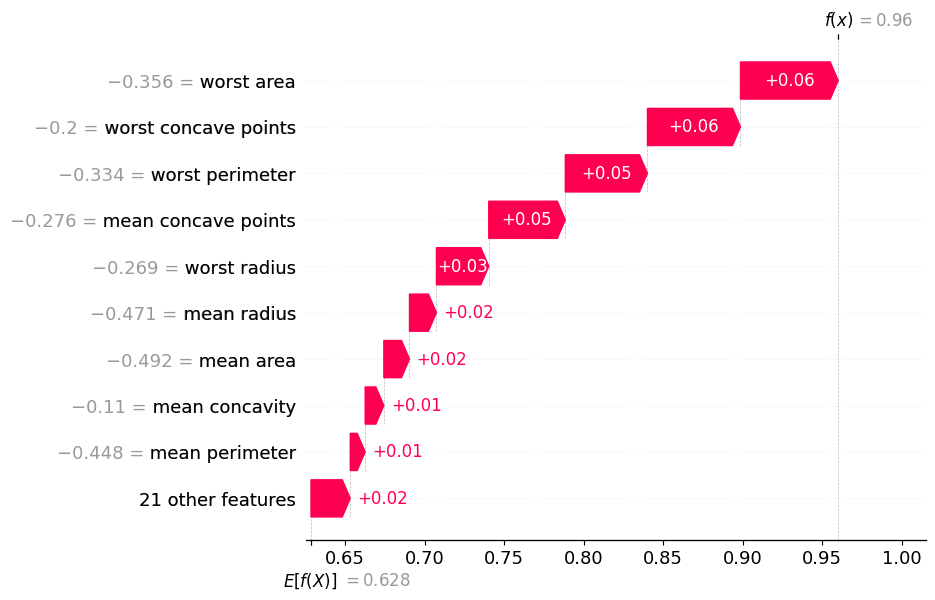

In [ ]:
#SHAP & Waterfall Plot
def shap_explain(model, sample_df, pred):

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(sample_df)

    if isinstance(shap_vals, list):
        shap_local = shap_vals[pred][0]
        base_val = explainer.expected_value[pred]
    else:
        shap_vals = np.array(shap_vals)
        shap_local = shap_vals[0, :, pred]
        base_val = explainer.expected_value[pred]

    shap_local = np.asarray(shap_local).flatten()

    explanation = shap.Explanation(
        values=shap_local,
        base_values=base_val,
        data=sample_df.values[0],
        feature_names=sample_df.columns
    )

    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    plt.savefig("shap_waterfall.png", bbox_inches="tight")
    plt.show()

    return shap_local

shap_local = shap_explain(model, sample_df, pred)

In [ ]:
# Top features
def get_top_features(shap_local, feature_names, k=5):
    idx = np.argsort(np.abs(shap_local))[::-1][:k]
    return [(feature_names[i], shap_local[i]) for i in idx]

top_features = get_top_features(shap_local, X.columns)

print("Top features:")
for f, v in top_features:
    print(f, round(v, 4))

Top features:
worst area 0.0615
worst concave points 0.0585
worst perimeter 0.0517
mean concave points 0.0482
worst radius 0.0329


In [ ]:
# Counterfactuals (DICE)
def generate_counterfactuals(model, X_train, y_train, sample_df):

    df = X_train.copy()
    df["target"] = y_train.values

    dice_data = dice_ml.Data(
        dataframe=df,
        continuous_features=list(X_train.columns),
        outcome_name="target"
    )

    dice_model = dice_ml.Model(model=model, backend="sklearn")
    dice = dice_ml.Dice(dice_data, dice_model)

    cf = dice.generate_counterfactuals(
        sample_df,
        total_CFs=config.num_counterfactuals,
        desired_class="opposite"
    )

    return cf.cf_examples_list[0].final_cfs_df

cf_df = generate_counterfactuals(model, X_train, y_train, sample_df)

print("Counterfactuals:")
display(cf_df)

100%|██████████| 1/1 [00:01<00:00,  1.69s/it]

Counterfactuals:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-0.470694,-0.160486,-0.44811,-0.491999,0.234114,0.027651,-0.109847,-0.276232,0.413949,0.132176,...,-0.168905,-0.333935,3.539177,0.448503,-0.104741,-0.024412,-0.199563,0.183204,0.196958,0
1,-0.470694,-0.160486,-0.44811,-0.491999,0.234114,0.027651,-0.109847,-0.276232,0.413949,0.132176,...,-0.168905,-0.333935,2.940278,0.448503,-0.104741,-0.024412,-0.199563,0.183204,0.196958,0


In [ ]:
# Extract CF Changes
def extract_cf_changes(sample, cf_df, feature_names):

    original = sample[0]
    changes_all = []

    for _, row in cf_df.iterrows():
        changes = {}
        for j, f in enumerate(feature_names):
            orig = float(original[j])
            new = float(row[f])

            if abs(orig - new) > 1e-3:
                changes[f] = (orig, new)

        changes_all.append(changes)

    return changes_all

cf_changes = extract_cf_changes(sample, cf_df, X.columns)

print("CF Changes:", cf_changes)

CF Changes: [{'worst radius': (-0.2690395121166662, 3.929895), 'worst area': (-0.35629924756098336, 3.53917701)}, {'worst radius': (-0.2690395121166662, 0.4871533), 'worst area': (-0.35629924756098336, 2.94027782)}]


In [ ]:
# Final Explaination
def format_final_output(label, top_features, cf_changes, confidence):

    mapped_terms = set()

    for f, _ in top_features:
        mapped_terms.add(explain_feature_name(f))

    mapped_terms = list(mapped_terms)[:3]
    feature_phrase = ", ".join(mapped_terms)

    decrease_detected = any(
        new < orig
        for changes in cf_changes
        for (orig, new) in changes.values()
    )

    action_text = (
        "reducing these values leads to a benign outcome"
        if decrease_detected
        else "increasing these values leads to a malignant outcome"
    )

    return (
        "LLM Explanation:\n"
        f" The prediction is influenced by features like {feature_phrase}. "
        f"Counterfactuals show that {action_text}.\n\n"
        f"Confidence Score: {round(confidence, 3)}\n\n"
        "![SHAP Waterfall](shap_waterfall.png)\n\n"
        " Report saved: xai_report.md"
    )

final_output = format_final_output(label, top_features, cf_changes, confidence)

print("\n" + final_output)


LLM Explanation:
 The prediction is influenced by features like tumor boundary length, tumor surface area, tumor size. Counterfactuals show that increasing these values leads to a malignant outcome.

Confidence Score: 0.96

![SHAP Waterfall](shap_waterfall.png)

 Report saved: xai_report.md


In [ ]:
#Report Generation
with open("xai_report.md", "w") as f:
    f.write(final_output)

print(" Report saved: xai_report.md")

 Report saved: xai_report.md


In [ ]:
def format_final_output(label, top_features, cf_changes, confidence):

    lines = []

    lines.append("Explanation:\n")
    lines.append(f"The model predicts this tumor as **{label}**.\n")

    # Key drivers
    lines.append("Key drivers:\n")

    for f, v in top_features:
        meaning = explain_feature_name(f)
        direction = "higher" if v > 0 else "lower"
        impact = "increases malignancy risk" if v > 0 else "supports benign outcome"

        lines.append(f"- {f} ({meaning}): {direction} → {impact}")

    # Counterfactuals
    lines.append("\nCounterfactual explanation:\n")

    increase_detected = False
    decrease_detected = False

    for i, changes in enumerate(cf_changes):
        lines.append(f"CF {i+1}:")

        for f, (orig, new) in changes.items():
            meaning = explain_feature_name(f)

            if new > orig:
                arrow = "↑"
                increase_detected = True
            else:
                arrow = "↓"
                decrease_detected = True

            lines.append(
                f"  {f} ({meaning}): {round(orig,2)} → {round(new,2)} {arrow}"
            )

        lines.append("")

    # Summary
    mapped_terms = list({
        explain_feature_name(f) for f, _ in top_features
    })[:3]

    feature_phrase = ", ".join(mapped_terms)

    if increase_detected and not decrease_detected:
        action = "increasing these values leads to a malignant outcome"
    elif decrease_detected and not increase_detected:
        action = "reducing these values leads to a benign outcome"
    else:
        action = "changing these values shifts the prediction outcome"

    lines.append(
        f"The prediction is influenced by features like {feature_phrase}. "
        f"Counterfactuals show that {action}.\n"
    )

    lines.append(f"Confidence Score: {round(confidence, 2)}\n")
    lines.append("![SHAP Waterfall](shap_waterfall.png)\n")
    lines.append("Report saved: xai_report.md")

    return "\n".join(lines)


final_output = format_final_output(label, top_features, cf_changes, confidence)

print("\n" + final_output)


Explanation:

The model predicts this tumor as **Benign**.

Key drivers:

- worst area (tumor surface area): higher → increases malignancy risk
- worst concave points (sharp indentations): higher → increases malignancy risk
- worst perimeter (tumor boundary length): higher → increases malignancy risk
- mean concave points (sharp indentations): higher → increases malignancy risk
- worst radius (tumor size): higher → increases malignancy risk

Counterfactual explanation:

CF 1:
  worst perimeter (tumor boundary length): -0.33 → 4.07 ↑
  worst area (tumor surface area): -0.36 → 1.17 ↑

CF 2:
  mean concave points (sharp indentations): -0.28 → 0.7 ↑
  worst concave points (sharp indentations): -0.2 → 2.61 ↑

The prediction is influenced by features like tumor boundary length, tumor surface area, tumor size. Counterfactuals show that increasing these values leads to a malignant outcome.

Confidence Score: 0.96

![SHAP Waterfall](shap_waterfall.png)

Report saved: xai_report.md


In [ ]:
with open("xai_report.md", "w") as f:
    f.write(final_output)

print(" Report saved: xai_report.md")

 Report saved: xai_report.md


Result with use of Openai API Key

In [ ]:
# Generate the feature list
def generate_counterfactuals(model, X_train, y_train, sample_df):

    df = X_train.copy()
    df["target"] = y_train.values

    dice_data = dice_ml.Data(
        dataframe=df,
        continuous_features=list(X_train.columns),
        outcome_name="target"
    )

    dice_model = dice_ml.Model(model=model, backend="sklearn")
    dice = dice_ml.Dice(dice_data, dice_model)

    cf = dice.generate_counterfactuals(
        sample_df,
        total_CFs=config.num_counterfactuals,
        desired_class="opposite"
    )

    return cf.cf_examples_list[0].final_cfs_df



# counterfactual changes
def highlight_cf_changes(sample, cf_df, feature_names):

    original = sample[0]
    outputs = []

    for i, row in cf_df.iterrows():
        lines = [f"CF {i+1}:"]

        for j, f in enumerate(feature_names):
            orig = float(original[j])
            new = float(row[f])

            if abs(orig - new) > 1e-3:

                arrow = "↓" if new < orig else "↑"
                meaning = explain_feature_name(f)

                lines.append(
                    f"  {f} ({meaning}): {round(orig,2)} → {round(new,2)} {arrow}"
                )

        outputs.append("\n".join(lines))

    return "\n\n".join(outputs)

# -----------------------------------------------------
# SMART FALLBACK
# -----------------------------------------------------

def fallback_explanation(top_features, cf_text, label):

    text = []
    text.append(f"The model predicts this tumor as **{label}**.\n")

    text.append("Key drivers:\n")
    for f, v in top_features:
        meaning = explain_feature_name(f)
        direction = "higher" if v > 0 else "lower"
        effect = "increases malignancy risk" if v > 0 else "supports benign"
        text.append(f"- {f} ({meaning}): {direction} → {effect}")

    text.append("\nCounterfactual explanation:\n")
    text.append(cf_text)

    text.append(
        "\nThese changes alter tumor size, shape, and irregularity, "
        "which are critical for distinguishing malignant vs benign tumors."
    )

    return "\n".join(text)

# -----------------------------------------------------
# OPENAI (OPTIONAL)
# -----------------------------------------------------

def run_llm(prompt, fallback_text):

    if not os.getenv("OPENAI_API_KEY"):
        return fallback_text

    try:
        client = OpenAI()
        res = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role":"user","content":prompt}],
            temperature=0.2,
            max_tokens=config.max_tokens
        )
        return res.choices[0].message.content

    except Exception as e:
        print(" OpenAI Error:", e)
        return fallback_text

# -----------------------------------------------------
# MAIN
# -----------------------------------------------------

def run_pipeline():

    X, y = load_data()
    X_train, X_test, y_train, y_test = preprocess(X, y)

    X_train = pd.DataFrame(X_train, columns=X.columns)
    X_test = pd.DataFrame(X_test, columns=X.columns)

    model = train_model(X_train, y_train)

    sample_df = X_test.iloc[[0]]
    sample = sample_df.values

    pred = model.predict(sample)[0]
    label = "Malignant" if pred == 0 else "Benign"

    print("Prediction:", label)

    # SHAP
    shap_local = shap_explain(model, X_train, sample_df, pred)
    top_features = get_top_features(shap_local, X.columns)

    # DiCE
    cf_df = generate_counterfactuals(model, X_train, y_train, sample_df)

    print("\nCounterfactuals:\n", cf_df)

    # Highlighted CF
    cf_text = highlight_cf_changes(sample, cf_df, X.columns)

    print("\nHighlighted Changes:\n")
    print(cf_text)

    # Fallback explanation
    fallback_text = fallback_explanation(top_features, cf_text, label)

    # Prompt
    prompt = f"""
Explain a breast cancer prediction.

Prediction: {label}
Top features: {top_features}

Counterfactual changes:
{cf_text}

Focus on WHY prediction flips.
"""

    explanation = run_llm(prompt, fallback_text)

    print("\nExplanation:\n")
    print(explanation)

    print("\n SHAP waterfall saved as shap_waterfall.png")

# -----------------------------------------------------
# RUN
# -----------------------------------------------------

run_pipeline()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction: Benign


100%|██████████| 1/1 [00:00<00:00,  1.86it/s]



Counterfactuals:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0    -0.470694     -0.160486        -0.44811  -0.491999         0.234114   
1    -0.470694     -0.160486        -0.44811  -0.491999         0.234114   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          0.027651       -0.109847            -0.276232       0.413949   
1          0.027651       -0.109847            -0.276232       0.413949   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                0.132176  ...      -0.168905         0.504092    2.676651   
1                0.132176  ...      -0.168905        -0.333935    0.632585   

   worst smoothness  worst compactness  worst concavity  worst concave points  \
0          0.448503          -0.104741        -0.024412             -0.199563   
1          0.448503          -0.104741        -0.024412             -0.199563   

   worst symmetry  worst fractal dimension  tar

Result without API

In [ ]:
# Features
top_idx = np.argsort(np.abs(shap_local))[::-1][:5]
top_features = [(X.columns[i], shap_local[i]) for i in top_idx]

# Counterfactual
df_dice = X_train.copy()
df_dice["target"] = y_train.values

dice_data = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=list(X.columns),
    outcome_name="target"
)

dice_model = dice_ml.Model(model=model, backend="sklearn")
dice = dice_ml.Dice(dice_data, dice_model)

cf = dice.generate_counterfactuals(
    sample_df,
    total_CFs=config.num_counterfactuals,
    desired_class="opposite"
)

cf_df = cf.cf_examples_list[0].final_cfs_df


# Extract Changes
def extract_cf_changes(sample, cf_df, feature_names):
    original = sample[0]
    changes_all = []

    for _, row in cf_df.iterrows():
        changes = {}
        for j, f in enumerate(feature_names):
            orig = float(original[j])
            new = float(row[f])
            if abs(orig - new) > 1e-3:
                changes[f] = (orig, new)
        changes_all.append(changes)

    return changes_all

cf_changes = extract_cf_changes(sample, cf_df, X.columns)

def format_final_output(label, top_features, cf_changes, confidence):

    lines = []

    lines.append("Explanation:\n")
    lines.append(f"The model predicts this tumor as **{label}**.\n")

    # Key drivers
    lines.append("Key drivers:\n")

    for f, v in top_features:
        meaning = explain_feature_name(f)
        direction = "higher" if v > 0 else "lower"
        impact = "increases malignancy risk" if v > 0 else "supports benign outcome"

        lines.append(f"- {f} ({meaning}): {direction} → {impact}")

    # Counterfactuals
    lines.append("\nCounterfactual explanation:\n")

    increase_detected = False
    decrease_detected = False

    for i, changes in enumerate(cf_changes):
        lines.append(f"CF {i+1}:")

        for f, (orig, new) in changes.items():
            meaning = explain_feature_name(f)

            if new > orig:
                arrow = "↑"
                increase_detected = True
            else:
                arrow = "↓"
                decrease_detected = True

            lines.append(
                f"  {f} ({meaning}): {round(orig,2)} → {round(new,2)} {arrow}"
            )

        lines.append("")

    # Summary
    mapped_terms = list({
        explain_feature_name(f) for f, _ in top_features
    })[:3]

    feature_phrase = ", ".join(mapped_terms)

    if increase_detected and not decrease_detected:
        action = "increasing these values leads to a malignant outcome"
    elif decrease_detected and not increase_detected:
        action = "reducing these values leads to a benign outcome"
    else:
        action = "changing these values shifts the prediction outcome"

    lines.append(
        f"The prediction is influenced by features like {feature_phrase}. "
        f"Counterfactuals show that {action}.\n"
    )

    # Confidence
    lines.append(f"Confidence Score: {round(confidence, 2)}\n")

    # Image
    lines.append("![SHAP Waterfall](shap_waterfall.png)\n")

    # Footer
    lines.append(" Report saved: xai_report.md")

    return "\n".join(lines)

final_output = format_final_output(label, top_features, cf_changes, confidence)

print("\n" + final_output)

with open("xai_report.md", "w") as f:
    f.write(final_output)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction: Benign
Confidence: 0.96


100%|██████████| 1/1 [00:00<00:00,  1.93it/s]


Explanation:

The model predicts this tumor as **Benign**.

Key drivers:

- worst area (tumor surface area): higher → increases malignancy risk
- worst concave points (sharp indentations): higher → increases malignancy risk
- worst perimeter (tumor boundary length): higher → increases malignancy risk
- mean concave points (sharp indentations): higher → increases malignancy risk
- worst radius (tumor size): higher → increases malignancy risk

Counterfactual explanation:

CF 1:
  worst perimeter (tumor boundary length): -0.33 → 4.07 ↑
  worst area (tumor surface area): -0.36 → 1.17 ↑

CF 2:
  mean concave points (sharp indentations): -0.28 → 0.7 ↑
  worst concave points (sharp indentations): -0.2 → 2.61 ↑

The prediction is influenced by features like tumor boundary length, tumor surface area, tumor size. Counterfactuals show that increasing these values leads to a malignant outcome.

Confidence Score: 0.96

![SHAP Waterfall](shap_waterfall.png)

✅ Report saved: xai_report.md


Result with API Key & Flip

In [ ]:
def get_top_features(shap_local, feature_names, k=5):
    idx = np.argsort(np.abs(shap_local))[::-1][:k]
    return [(feature_names[i], shap_local[i]) for i in idx], idx

def format_counterfactuals(sample, cf_df, feature_names):
    original = sample[0]
    changes_all = []

    for _, row in cf_df.iterrows():
        changes = {}
        for j, f in enumerate(feature_names):
            if abs(original[j] - row[f]) > 1e-3:
                changes[f] = (original[j], row[f])
        changes_all.append(changes)

    return changes_all


# Counterfactual
def generate_counterfactuals(model, X_train, y_train, sample_df):

    df = X_train.copy()
    df["target"] = y_train.values

    dice_data = dice_ml.Data(
        dataframe=df,
        continuous_features=list(X_train.columns),
        outcome_name="target"
    )

    dice_model = dice_ml.Model(model=model, backend="sklearn")
    dice = dice_ml.Dice(dice_data, dice_model)

    cf = dice.generate_counterfactuals(
        sample_df,
        total_CFs=config.num_counterfactuals,
        desired_class="opposite"
    )

    return cf.cf_examples_list[0].final_cfs_df


# Fallback Option
def fallback_explanation(top_features, cf_changes, label):

    explanation = []

    explanation.append(f"Prediction: {label}\n")

    explanation.append("Key influencing features:\n")

    for f, v in top_features:
        direction = "higher" if v > 0 else "lower"
        effect = "increases malignancy risk" if v > 0 else "suggests benign behaviour"

        explanation.append(f"- {f}: {direction} value → {effect}")

    explanation.append("\nCounterfactual reasoning:\n")

    for i, changes in enumerate(cf_changes):
        explanation.append(f"CF {i+1}:")

        for f, (orig, new) in changes.items():
            trend = "decreased" if new < orig else "increased"
            explanation.append(
                f"- {f}: {round(orig,2)} → {round(new,2)} ({trend})"
            )

        explanation.append(
            "→ These changes reduce malignant characteristics, flipping the prediction.\n"
        )

    explanation.append("Clinical insight:")
    explanation.append(
        "Features related to cell size, perimeter, and texture are key indicators. "
        "Lower and more regular values are typically associated with benign tumors."
    )

    return "\n".join(explanation)


# llm explanation
def run_llm(prompt, top_features, cf_changes, label):

    if not os.getenv("OPENAI_API_KEY"):
        return fallback_explanation(top_features, cf_changes, label)

    client = OpenAI()

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You explain medical ML predictions."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2,
            max_tokens=config.max_tokens
        )

        return response.choices[0].message.content

    except Exception as e:
        print("OpenAI Error:", e)
        return fallback_explanation(top_features, cf_changes, label)


# Main pipeline
def run_pipeline():

    X, y = load_data()
    X_train, X_test, y_train, y_test = preprocess(X, y)

    X_train = pd.DataFrame(X_train, columns=X.columns)
    X_test = pd.DataFrame(X_test, columns=X.columns)

    model = train_model(X_train, y_train)

    sample_df = X_test.iloc[[0]]
    sample = sample_df.values

    pred = model.predict(sample)[0]
    label = "Malignant" if pred == 0 else "Benign"

    print("Prediction:", label)

    shap_local = get_shap_values(model, X_train, sample, pred)

    top_features, top_idx = get_top_features(shap_local, X.columns)

    cf_df = generate_counterfactuals(model, X_train, y_train, sample_df)

    cf_changes = format_counterfactuals(sample, cf_df, X.columns)

    # Prompt (used only if API works)
    prompt = f"""
Explain this breast cancer prediction using feature importance and counterfactuals.

Prediction: {label}
Top features: {top_features}
Counterfactual changes: {cf_changes}
"""

    explanation = run_llm(prompt, top_features, cf_changes, label)

    print("\nExplanation:\n")
    print(explanation)
run_pipeline()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction: Benign


100%|██████████| 1/1 [00:01<00:00,  1.80s/it]


⚠️ OpenAI Error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: ck_41f51*******************************************************d963. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

Explanation:

Prediction: Benign

Key influencing features:

- worst area: higher value → increases malignancy risk
- worst concave points: higher value → increases malignancy risk
- worst perimeter: higher value → increases malignancy risk
- mean concave points: higher value → increases malignancy risk
- worst radius: higher value → increases malignancy risk

Counterfactual reasoning:

CF 1:
- mean concave points: -0.28 → 1.94 (increased)
- worst concave points: -0.2 → 1.74 (increased)
→ These changes reduce malignant characteristics, flipping the prediction.

CF 2:
- mean concave points: -0.28 → 2.78 (increased)
- worst concave points: -0.2 → 2.26 (increased)
→ These changes reduc